In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.neighbors import BallTree
import os
import folium


import sys
sys.path.append('../src')
from functions import (percentile_rank, 
                       haversine, 
                       ais_gap_analysis, 
                       detect_sts_events, 
                       route_irregularity_analysis, 
                       name_change_analysis, 
                       compute_vessel_risk, 
                       risk_category, 
                       run_anomaly_detection
                       
)

In [2]:
# SAMPLE DATA FOR TESTING 

df0 = pd.read_csv("../data/raw/AIS_2018_09_30.csv")

row_num = 1000000
df0.head(row_num).to_csv(f"../data/processed/ais_sample{row_num}.csv", index=False)

In [3]:
# LOADING AND SORTING THE DATA #

filepath = f'../data/processed/ais_sample{row_num}.csv'

df = pd.read_csv(filepath) 


df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"]) # Convert to datetime

df = df.sort_values(['MMSI', 'BaseDateTime'])


In [4]:
# # ANALYZING AIS TRANSMISSION GAPS #


# print (ais_gap_analysis(df).head())

# gap_summary = ais_gap_analysis(df)

# if gap_summary['gap_count'].sum() > 0:
#     plt.figure(figsize=(10,6))
#     sns.histplot(gap_summary[gap_summary["gap_count"] > 0]["gap_count"], bins=20) # Plot only vessels with at least one gap
#     plt.title("Distribution of AIS Transmission Gaps")
#     plt.xlabel(f"Number of total AIS gaps per vessel")
#     plt.ylabel("Count")
#     plt.show()

# if gap_summary['minor_gaps'].sum() > 0:
#     plt.figure(figsize=(10,6))
#     sns.histplot(gap_summary[gap_summary["minor_gaps"] > 0]["minor_gaps"], bins=20, color = 'yellow') # Plot only vessels with at least one gap
#     plt.title("Distribution of AIS Transmission Gaps")
#     plt.xlabel(f"Number of minor AIS gaps per vessel")
#     plt.ylabel("Count")
#     plt.show()

# if gap_summary['major_gaps'].sum() > 0:
#     plt.figure(figsize=(10,6))
#     sns.histplot(gap_summary[gap_summary["major_gaps"] > 0]["major_gaps"], bins=20, color = 'orange') # Plot only vessels with at least one gap
#     plt.title("Distribution of AIS Transmission Gaps")
#     plt.xlabel(f"Number of major AIS gaps per vessel")
#     plt.ylabel("Count")
#     plt.show()

# if gap_summary['dark_gaps'].sum() > 0:
#     plt.figure(figsize=(10,6))
#     sns.histplot(gap_summary[gap_summary["dark_gaps"] > 0]["dark_gaps"], bins=20, color = 'red') # Plot only vessels with at least one gap
#     plt.title("Distribution of AIS Transmission Gaps")
#     plt.xlabel(f"Number of dark AIS gaps per vessel")
#     plt.ylabel("Count")
#     plt.show()

In [5]:
# sts_df, sts_counts = detect_sts_events(df)

In [6]:
# ri = route_irregularity_analysis(df)

# ri.head()

In [7]:
# events, counts, multi_names = name_change_analysis(df)

# print("Vessels with multiple names associated with the same MMSI:")
# print(multi_names) 

In [8]:
indicators = compute_vessel_risk(
    df,
    gap_summary=ais_gap_analysis(df),
)

print(indicators['Risk_Score'])
indicators.to_csv(f"../data/processed/vessel_risk_indicators{row_num}.csv", index=False)

Starting STS detection
Total AIS points: 1000000
Unique vessels: 1825

Filtering low-speed AIS points (SOG < 2 knots)
Candidate AIS points: 773097
Total space-time groups: 34498
Processing group 0/34498
Processing group 500/34498
Processing group 1000/34498
Processing group 1500/34498
Processing group 2000/34498
Processing group 2500/34498
Processing group 3000/34498
Processing group 3500/34498
Processing group 4000/34498
Processing group 4500/34498
Processing group 5000/34498
Processing group 5500/34498
Processing group 6000/34498
Processing group 6500/34498
Processing group 7000/34498
Processing group 7500/34498
Processing group 8000/34498
Processing group 8500/34498
Processing group 9000/34498
Processing group 9500/34498
Processing group 10000/34498
Processing group 10500/34498
Processing group 11000/34498
Processing group 11500/34498
Processing group 12000/34498
Processing group 12500/34498
Processing group 13000/34498
Processing group 13500/34498
Processing group 14000/34498
Proce

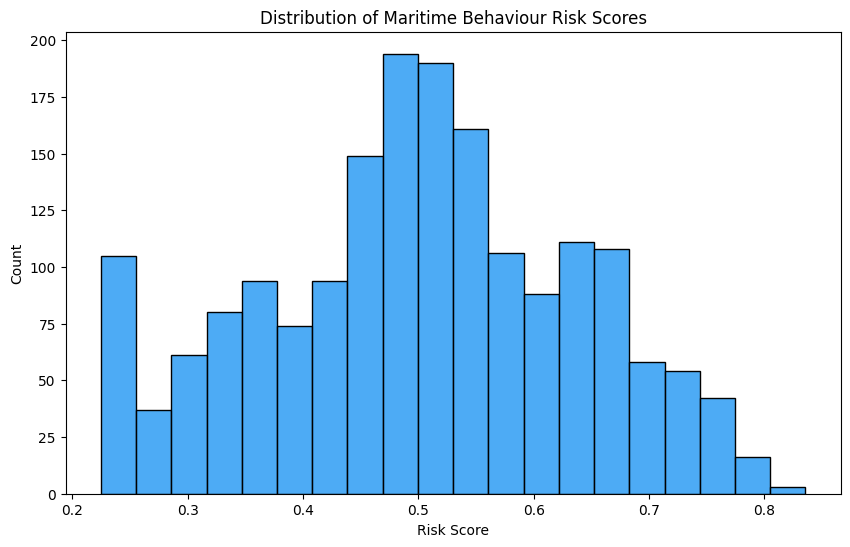

In [9]:

plt.figure(figsize=(10,6))

# Plot histogram of Risk_Score without category coloring
sns.histplot(
    data=indicators,
    x="Risk_Score",
    bins=20,
    color="#2196F3",
    alpha=0.8
)

plt.title("Distribution of Maritime Behaviour Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()


In [10]:
high_risk = indicators[indicators["Risk_Score"] >= 2] # Define high risk as Risk_Score of 2 or above
low_risk = indicators[indicators["Risk_Score"] == 0]

print("High risk avg:")
print(high_risk.mean(numeric_only=True))

print("\nLow risk avg:")
print(low_risk.mean(numeric_only=True))

High risk avg:
AIS_Gap_Count        NaN
Route_Irregularity   NaN
STS_Count            NaN
Name_Change_Count    NaN
gap_score            NaN
route_score          NaN
sts_score            NaN
name_score           NaN
Risk_Score           NaN
flag_gap             NaN
flag_route           NaN
flag_sts             NaN
flag_name            NaN
Flag_Count           NaN
dtype: float64

Low risk avg:
AIS_Gap_Count        NaN
Route_Irregularity   NaN
STS_Count            NaN
Name_Change_Count    NaN
gap_score            NaN
route_score          NaN
sts_score            NaN
name_score           NaN
Risk_Score           NaN
flag_gap             NaN
flag_route           NaN
flag_sts             NaN
flag_name            NaN
Flag_Count           NaN
dtype: float64


In [12]:
top_vessel = indicators.sort_values("Risk_Score", ascending=False).index[0]

vessel_df = df[df["MMSI"] == top_vessel].copy()

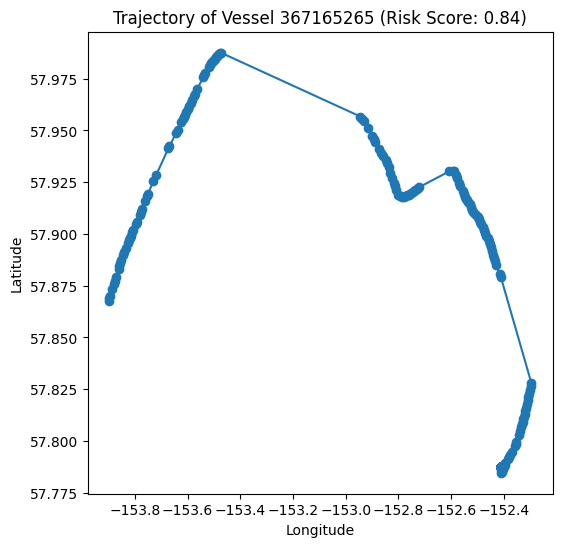

In [28]:
plt.figure(figsize=(6,6))
plt.plot(vessel_df["LON"], vessel_df["LAT"], marker='o')
plt.title(f"Trajectory of Vessel {top_vessel} (Risk Score: {indicators.loc[top_vessel, 'Risk_Score']:.2f})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Starting STS detection
Total AIS points: 1000000
Unique vessels: 1825

Filtering low-speed AIS points (SOG < 2 knots)
Candidate AIS points: 773097
Total space-time groups: 34498
Processing group 0/34498
Processing group 500/34498
Processing group 1000/34498
Processing group 1500/34498
Processing group 2000/34498
Processing group 2500/34498
Processing group 3000/34498
Processing group 3500/34498
Processing group 4000/34498
Processing group 4500/34498
Processing group 5000/34498
Processing group 5500/34498
Processing group 6000/34498
Processing group 6500/34498
Processing group 7000/34498
Processing group 7500/34498
Processing group 8000/34498
Processing group 8500/34498
Processing group 9000/34498
Processing group 9500/34498
Processing group 10000/34498
Processing group 10500/34498
Processing group 11000/34498
Processing group 11500/34498
Processing group 12000/34498
Processing group 12500/34498
Processing group 13000/34498
Processing group 13500/34498
Processing group 14000/34498
Proce

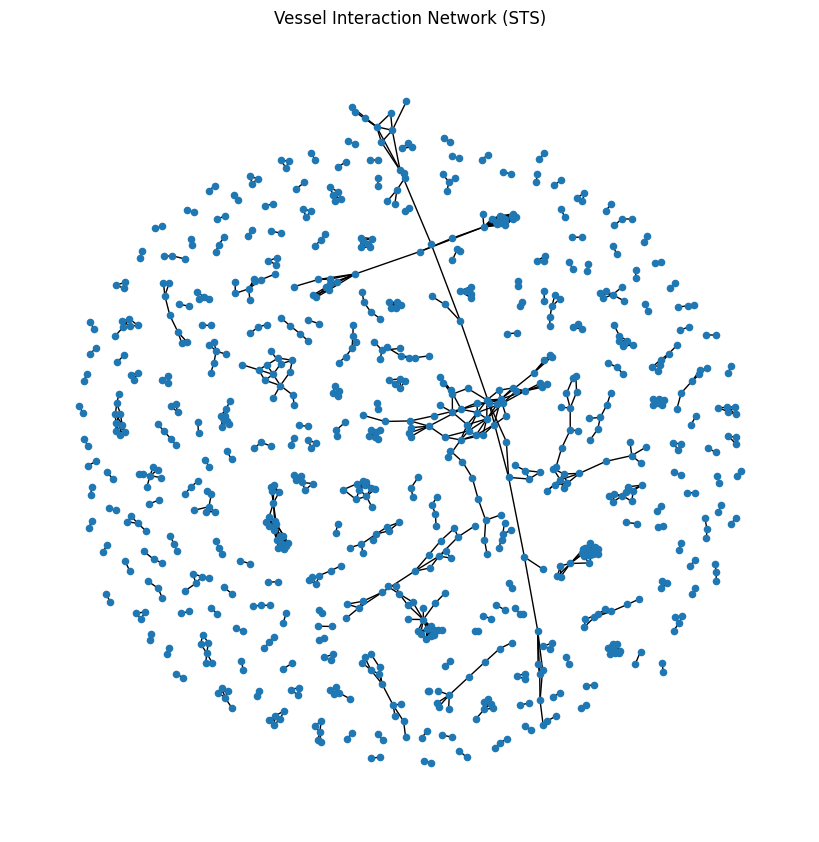

In [14]:
# Make sure sts_df is defined
sts_df, sts_counts = detect_sts_events(df)

import networkx as nx

# Create a graph where nodes are vessels and edges represent STS interactions

G = nx.Graph() 

for _, row in sts_df.iterrows():
    G.add_edge(row["MMSI1"], row["MMSI2"])

plt.figure(figsize=(8,8))
nx.draw(G, node_size=20)
plt.title("Vessel Interaction Network (STS)")
plt.show()

In [15]:
indicators = run_anomaly_detection(indicators)

# Top suspicious vessels
suspicious = indicators.sort_values("anomaly_score_raw").head(10)

print(suspicious)

           AIS_Gap_Count  Route_Irregularity  STS_Count  Name_Change_Count  \
367735180             11            0.000646    47919.0                0.0   
338184299             43            0.000616      456.0                0.0   
338225406             38            0.000696     1622.0                0.0   
367165265              9            1.146180    98055.0                0.0   
367143140             42            0.000984     1482.0                0.0   
367549180             15            0.000973    14443.0                0.0   
941206075             12            0.037017    56786.0                0.0   
367660080             19            0.000531     2666.0                0.0   
368053210              6            0.291987   101691.0                0.0   
339413000             31            0.000779      772.0                0.0   

           gap_score  route_score  sts_score  name_score  Risk_Score  \
367735180   0.852055     0.062466   0.984110    0.500274    0.680986 

In [16]:
indicators["priority"] = (
    indicators["Risk_Score"] * 0.6 +
    (indicators["is_anomalous"].astype(int)) * 0.4
)

print(indicators.sort_values("priority", ascending=False).head(3))

           AIS_Gap_Count  Route_Irregularity  STS_Count  Name_Change_Count  \
367165265              9            1.146180    98055.0                0.0   
366743980             13            1.442334     8852.0                0.0   
367112630             22            1.571326     2006.0                0.0   

           gap_score  route_score  sts_score  name_score  Risk_Score  \
367165265   0.795342     0.915616   0.996712    0.500274    0.835548   
366743980   0.882192     0.925479   0.875616    0.500274    0.831589   
367112630   0.945479     0.928767   0.716712    0.500274    0.806726   

           flag_gap  flag_route  flag_sts  flag_name  Flag_Count  \
367165265     False        True      True      False           2   
366743980      True        True      True      False           3   
367112630      True        True     False      False           2   

           anomaly_score  anomaly_score_raw  is_anomalous  priority  
367165265             -1          -0.049681          Tr

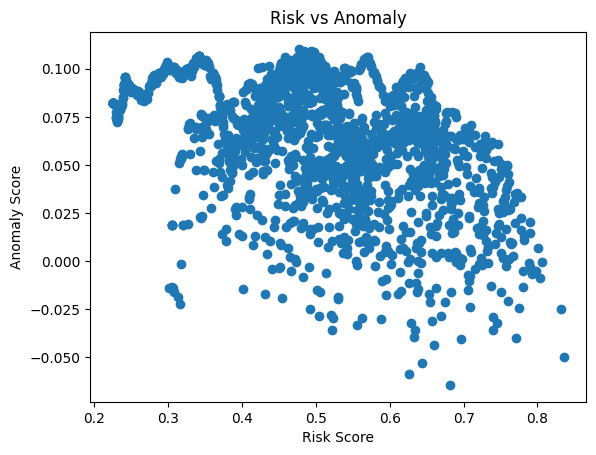

In [17]:
plt.scatter(
    indicators["Risk_Score"],
    indicators["anomaly_score_raw"]
)

plt.xlabel("Risk Score")
plt.ylabel("Anomaly Score")
plt.title("Risk vs Anomaly")

plt.show()

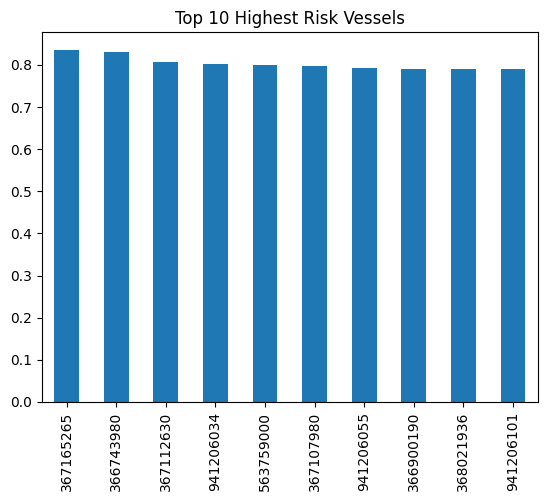

In [21]:
top = indicators.sort_values("Risk_Score", ascending=False).head(10)

top["Risk_Score"].plot(kind="bar")
plt.title("Top 10 Highest Risk Vessels")
plt.show()

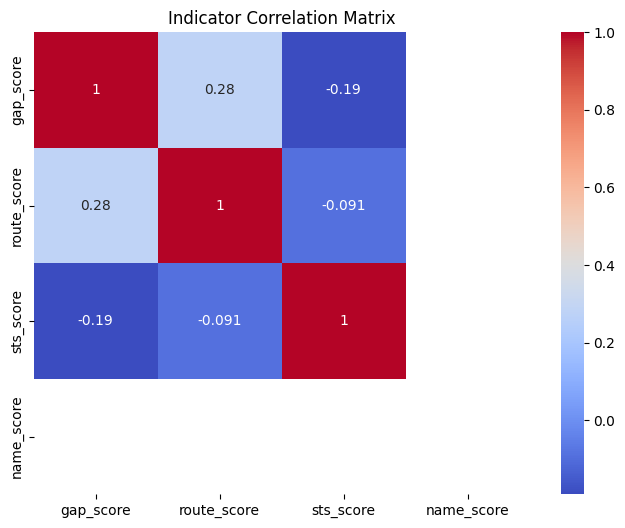

In [23]:
plt.figure(figsize=(8,6))

corr = indicators[[
    'gap_score',
    'route_score',
    'sts_score',
    'name_score'
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Indicator Correlation Matrix")
plt.show()

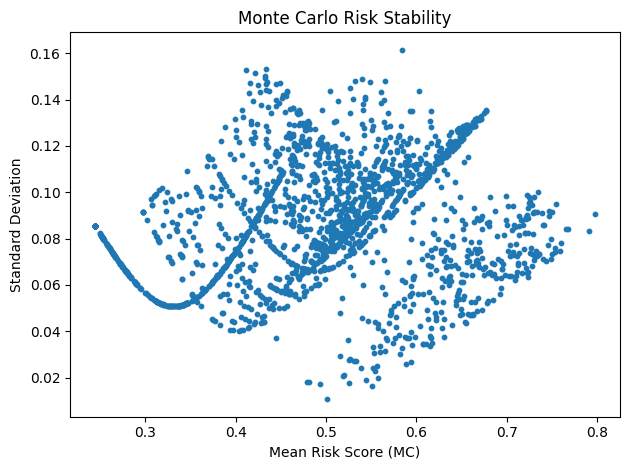

In [27]:
def monte_carlo_risk(indicators, n_sim=100):
    import numpy as np

    base_features = [
        "gap_score",
        "loiter_score",
        "sts_score",
        "name_score"
    ]

    results = []

    for i in range(n_sim):

        # Random weights that sum to 1
        w = np.random.dirichlet(np.ones(len(base_features)))

        risk = (
            w[0]*indicators["gap_score"] +
            w[1]*indicators["route_score"] +
            w[2]*indicators["sts_score"] +
            w[3]*indicators["name_score"]
        )

        results.append(risk)

    mc_matrix = np.vstack(results)

    # Statistics per vessel
    indicators["mc_mean"] = mc_matrix.mean(axis=0)
    indicators["mc_std"] = mc_matrix.std(axis=0)

    return indicators, mc_matrix


monte_carlo_results, mc_matrix = monte_carlo_risk(indicators)

plt.figure()
plt.scatter(indicators["mc_mean"], indicators["mc_std"], s=10)

plt.xlabel("Mean Risk Score (MC)")
plt.ylabel("Standard Deviation")
plt.title("Monte Carlo Risk Stability")
plt.tight_layout()
plt.show()

In [ ]:
!pip install folium

In [29]:
import folium

m = folium.Map(location=[df['LAT'].mean(), df['LON'].mean()], zoom_start=2, tiles='CartoDB positron'
               )

In [30]:
for mmsi, vessel in df.groupby('MMSI'):
    coords = list(zip(vessel['LAT'], vessel['LON'])) 

    if len(coords) > 2:

        folium.PolyLine(coords, color='blue', weight=1, opacity=0.4).add_to(m)

In [ ]:
for mmsi, row in indicators.iterrows():

    vessel_data = df[df['MMSI'] == mmsi]

    if len(vessel_data) == 0:
        continue

    last_point = vessel_data.iloc[-1]

    risk = row['Risk_Score']

    folium.CircleMarker(
        location=[last_point['LAT'], last_point['LON']],
        radius=3 + risk*10,
        color='red' if risk > 0.7 else 'orange',
        fill=True,
        fill_opacity=0.7,
        popup=f"MMSI:{mmsi} Risk:{round(risk,2)}"
    ).add_to(m)

# STS HOTSPOT LOCATIONS

if len(sts_df) > 0:

    sts_points = []

    for _, row in sts_df.iterrows():

        v1_data = df[df['MMSI'] == row['MMSI1']]
        v2_data = df[df['MMSI'] == row['MMSI2']]

        if v1_data.empty or v2_data.empty:
            continue

        v1 = v1_data.iloc[-1]
        v2 = v2_data.iloc[-1]

        lat_mid = (v1['LAT'] + v2['LAT'])/2
        lon_mid = (v1['LON'] + v2['LON'])/2

        sts_points.append((lat_mid, lon_mid))

    for lat, lon in sts_points:

        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            color='purple',
            fill=True
        ).add_to(m)

m


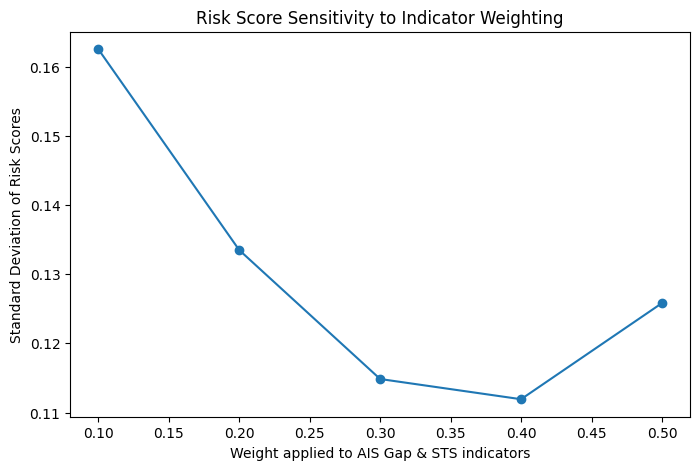

In [ ]:


weights_range = [0.1,0.2,0.3,0.4,0.5]

results = []

for w in weights_range:

    temp_score = (
        w * indicators["gap_score"] +
        w * indicators["sts_score"] +
        (1-2*w) * (
            indicators["loiter_score"] +
            indicators["route_score"]
        ) / 2
    )

    results.append(temp_score.std())

plt.figure(figsize=(8,5))

plt.plot(weights_range, results, marker="o")

plt.title("Risk Score Sensitivity to Indicator Weighting")

plt.xlabel("Weight applied to AIS Gap & STS indicators")

plt.ylabel("Standard Deviation of Risk Scores")

plt.show()

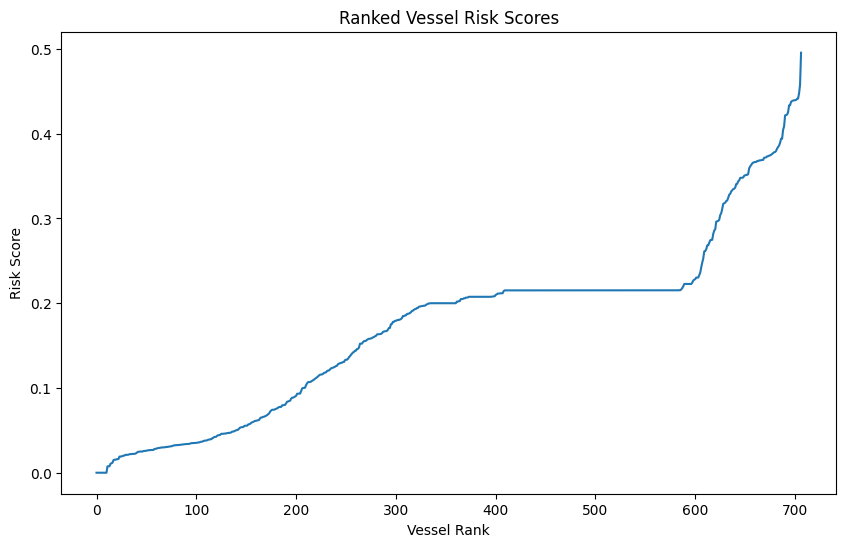

In [ ]:

sorted_scores = indicators["Risk_Score"].sort_values()

plt.figure(figsize=(10,6))

plt.plot(sorted_scores.values)

plt.title("Ranked Vessel Risk Scores")

plt.xlabel("Vessel Rank")
plt.ylabel("Risk Score")

plt.show()